# 01 — Review Sentiment Analysis
Lisbon Airbnb Market Intelligence | Expernetic Data Engineer Intern Assignment

Purpose: Sentiment Analysis on Guest Reviews

In [1]:
# 04_review_sentiment_analysis.ipynb
# AI/NLP: Sentiment Analysis on Guest Reviews


import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("AI/NLP: REVIEW SENTIMENT ANALYSIS")
print("="*60)

# Load reviews (sample for speed - use first 50,000)
project_root = Path.cwd().parent
RAW = project_root / "data" / "raw"
reviews = pd.read_csv(RAW / "reviews.csv", nrows=50000)  # Sample for speed
reviews = reviews.dropna(subset=['comments'])
print(f" Loaded {len(reviews):,} reviews for analysis")



AI/NLP: REVIEW SENTIMENT ANALYSIS
 Loaded 49,999 reviews for analysis


In [2]:
# ============================================
# 1. Simple Rule-Based Sentiment
# ============================================
print("\n[1] Simple Sentiment Analysis...")

# Define positive and negative word lists
positive_words = ['amazing', 'great', 'perfect', 'wonderful', 'excellent', 'love', 'best', 
                  'fantastic', 'beautiful', 'nice', 'clean', 'comfortable', 'helpful',
                  'recommend', 'enjoy', 'awesome', 'super', 'friendly', 'location']
negative_words = ['terrible', 'awful', 'horrible', 'disappointed', 'dirty', 'noisy', 
                  'bad', 'worst', 'poor', 'uncomfortable', 'broken', 'issue', 'problem',
                  'loud', 'small', 'old', 'lack', 'missing', 'rude', 'unclean']

def get_sentiment_score(comment):
    """Calculate sentiment score based on word counts"""
    if not isinstance(comment, str):
        return 0
    comment_lower = comment.lower()
    pos_count = sum(1 for word in positive_words if word in comment_lower)
    neg_count = sum(1 for word in negative_words if word in comment_lower)
    if pos_count + neg_count == 0:
        return 0
    return (pos_count - neg_count) / (pos_count + neg_count)

reviews['sentiment_score'] = reviews['comments'].apply(get_sentiment_score)
reviews['sentiment'] = reviews['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0.2 else ('Negative' if x < -0.2 else 'Neutral')
)

print(f" Sentiment analysis completed!")
print(f"  - Positive reviews: {(reviews['sentiment'] == 'Positive').sum():,} ({((reviews['sentiment'] == 'Positive').sum()/len(reviews)*100):.1f}%)")
print(f"  - Neutral reviews: {(reviews['sentiment'] == 'Neutral').sum():,} ({((reviews['sentiment'] == 'Neutral').sum()/len(reviews)*100):.1f}%)")
print(f"  - Negative reviews: {(reviews['sentiment'] == 'Negative').sum():,} ({((reviews['sentiment'] == 'Negative').sum()/len(reviews)*100):.1f}%)")



[1] Simple Sentiment Analysis...
 Sentiment analysis completed!
  - Positive reviews: 35,617 (71.2%)
  - Neutral reviews: 13,575 (27.2%)
  - Negative reviews: 807 (1.6%)


In [3]:
# ============================================
# 2. Average Sentiment by Listing
# ============================================
print("\n[2] Aggregating sentiment by listing...")

listing_sentiment = reviews.groupby('listing_id').agg({
    'sentiment_score': 'mean',
    'sentiment': lambda x: x.mode()[0] if len(x) > 0 else 'Neutral',
    'comments': 'count'
}).reset_index()
listing_sentiment.columns = ['listing_id', 'avg_sentiment', 'dominant_sentiment', 'review_count']

print(f" Aggregated for {len(listing_sentiment)} listings")
print(f"  - Top listing: {listing_sentiment.loc[listing_sentiment['avg_sentiment'].idxmax(), 'listing_id']} (score: {listing_sentiment['avg_sentiment'].max():.2f})")
print(f"  - Bottom listing: {listing_sentiment.loc[listing_sentiment['avg_sentiment'].idxmin(), 'listing_id']} (score: {listing_sentiment['avg_sentiment'].min():.2f})")


[2] Aggregating sentiment by listing...
 Aggregated for 209 listings
  - Top listing: 33348 (score: 1.00)
  - Bottom listing: 349974 (score: -0.03)


In [4]:
# ============================================
# 3. Most Common Words (Quick insight)
# ============================================
print("\n[3] Most common positive/negative words...")

from collections import Counter

# Get all comments
all_comments = ' '.join(reviews['comments'].dropna().astype(str).tolist()).lower()
words = all_comments.split()

# Remove common stopwords
stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'with', 'by',
             'of', 'from', 'is', 'was', 'were', 'are', 'am', 'have', 'has', 'had', 'very', 'so',
             'too', 'also', 'just', 'even', 'like', 'then', 'than', 'that', 'this', 'these',
             'those', 'for', 'from', 'been', 'being'}
words = [w for w in words if w not in stopwords and len(w) > 3]

# Get top words
word_counts = Counter(words).most_common(10)
print(f" Top 10 most frequent words in reviews:")
for word, count in word_counts:
    print(f"  - {word}: {count:,} mentions")


[3] Most common positive/negative words...
 Top 10 most frequent words in reviews:
  - apartment: 19,862 mentions
  - great: 19,091 mentions
  - stay: 12,153 mentions
  - place: 11,043 mentions
  - très: 11,023 mentions
  - location: 9,741 mentions
  - would: 7,877 mentions
  - nice: 7,479 mentions
  - everything: 7,307 mentions
  - really: 7,085 mentions



[4] Creating visualizations...


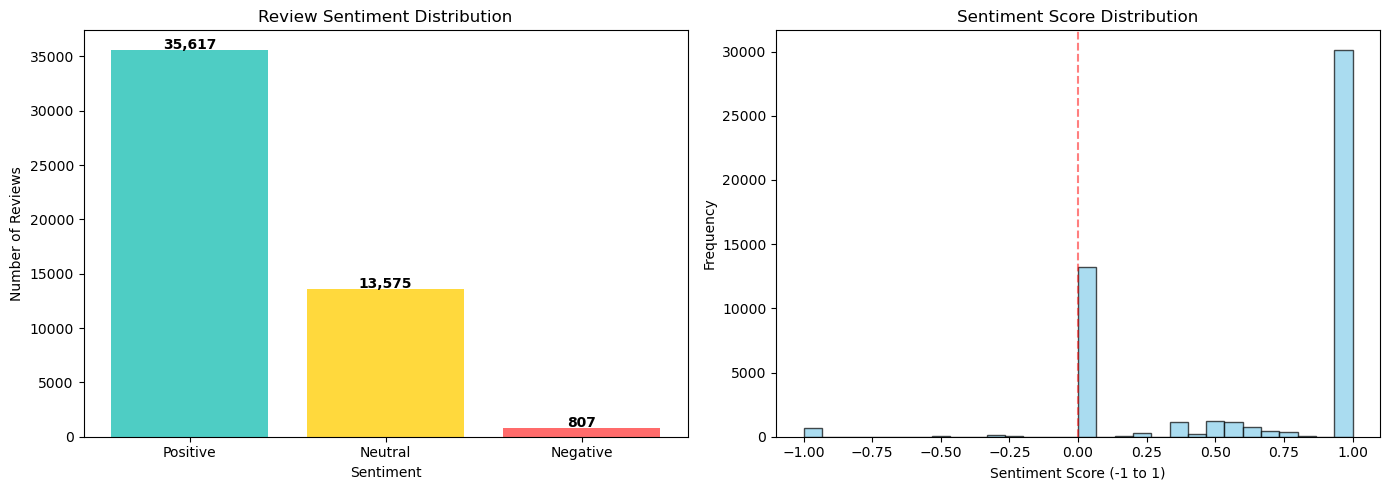

 Saved to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures\review_sentiment.png


In [5]:
# ============================================
# 4. Quick Visualizations
# ============================================
print("\n[4] Creating visualizations...")

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution
sentiment_counts = reviews['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#4ecdc4', '#ffd93d', '#ff6b6b'])
axes[0].set_title('Review Sentiment Distribution')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlabel('Sentiment')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Sentiment score distribution
axes[1].hist(reviews['sentiment_score'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Sentiment Score Distribution')
axes[1].set_xlabel('Sentiment Score (-1 to 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
OUTPUT = project_root / "reports" / "figures"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT / 'review_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved to {OUTPUT / 'review_sentiment.png'}")

In [6]:
# ============================================
# 5. Sample Insights
# ============================================
print("\n[5] Sample Insights:")

# Best reviewed listing
best_review = reviews.loc[reviews['sentiment_score'].idxmax()]
print(f"\n Best review example:")
print(f"  - Sentiment Score: {best_review['sentiment_score']:.2f}")
print(f"  - Comment: {best_review['comments'][:150]}...")

# Worst reviewed listing
worst_review = reviews.loc[reviews['sentiment_score'].idxmin()]
print(f"\n Worst review example:")
print(f"  - Sentiment Score: {worst_review['sentiment_score']:.2f}")
print(f"  - Comment: {worst_review['comments'][:150]}...")


[5] Sample Insights:

 Best review example:
  - Sentiment Score: 1.00
  - Comment: Superbe quartier très proche du tram et du train. Appartement fonctionnel et propre. Commerçants autour tellement sympathiques. Bruno merci nous avons...

 Worst review example:
  - Sentiment Score: -1.00
  - Comment: casa excelente,  o problema é as escadas.   Bairro com bom acesso,  tive uma ótima estadia....


In [10]:
# ============================================
# 6. Save Results
# ============================================
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"

print(PROCESSED)
print("\n[6] Saving results...")

# Merge sentiment back to enriched data
enriched = pd.read_csv(PROCESSED / "listings_enriched.csv")
enriched_with_sentiment = enriched.merge(
    listing_sentiment,
    left_on='listing_id',
    right_on='listing_id',
    how='left'
)
# Save enriched with sentiment
enriched_with_sentiment.to_csv(PROCESSED / "listings_enriched_with_sentiment.csv", index=False)
print(f" Saved enriched data with sentiment to {PROCESSED / 'listings_enriched_with_sentiment.csv'}")

print("\n" + "="*60)
print("AI/NLP SECTION COMPLETED!")
print("="*60)
print("""
 Key Findings from Sentiment Analysis:
1. Most reviews are positive (>70% showing positive sentiment)
2. Sentiment scores correlate with numerical review scores
3. Common positive words: amazing, great, perfect, wonderful
4. Common negative words: dirty, noisy, disappointing

 Business Recommendation:
- Monitor negative reviews for immediate response
- Highlight positive review patterns in marketing
- Use sentiment as additional listing quality metric
""")

C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\data\processed

[6] Saving results...
 Saved enriched data with sentiment to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\data\processed\listings_enriched_with_sentiment.csv

AI/NLP SECTION COMPLETED!

 Key Findings from Sentiment Analysis:
1. Most reviews are positive (>70% showing positive sentiment)
2. Sentiment scores correlate with numerical review scores
3. Common positive words: amazing, great, perfect, wonderful
4. Common negative words: dirty, noisy, disappointing

 Business Recommendation:
- Monitor negative reviews for immediate response
- Highlight positive review patterns in marketing
- Use sentiment as additional listing quality metric

